In [7]:
import pandas as pd
import numpy as np

In [8]:
abm = pd.read_parquet("abm.parquet")
card = pd.read_parquet("card.parquet")
cheque = pd.read_parquet("cheque.parquet")
eft = pd.read_parquet("eft.parquet")
emt = pd.read_parquet("emt.parquet")
westernUnion = pd.read_parquet("westernunion.parquet")
wire = pd.read_parquet("wire.parquet")

channels = {
    "ABM": abm,
    "Card": card,
    "Cheque": cheque,
    "EFT": eft,
    "EMT": emt,
    "Western Union": westernUnion,
    "Wire": wire
}

kyc_ind = pd.read_parquet("kyc_individual.parquet")
kyc_ind_codes = pd.read_parquet("kyc_industry_codes.parquet")
kyc_occ_codes = pd.read_parquet("kyc_occupation_codes.parquet")
kyc_sb = pd.read_parquet("kyc_smallbusiness.parquet")
label = pd.read_parquet("labels.parquet")

In [9]:
def coerce_code_to_str(df, col):
    if col in df.columns:
        df = df.copy()
        df[col] = df[col].astype("string").str.strip()
    return df

# --- 1) Stack transactions ---
transactions = []
for channel_name, df in channels.items():
    d = df.copy()
    d["channel"] = channel_name

    d = d.rename(columns={
        "country": "tx_country",
        "province": "tx_province",
        "city": "tx_city"})

    transactions.append(d)

tx = pd.concat(transactions, axis=0, ignore_index=True)

# 2) Coerce join keys for KYC code tables
kyc_ind_  = coerce_code_to_str(kyc_ind, "occupation_code")
kyc_occ_  = coerce_code_to_str(kyc_occ_codes, "occupation_code")

kyc_sb_   = coerce_code_to_str(kyc_sb, "industry_code")
kyc_indc_ = coerce_code_to_str(kyc_ind_codes, "industry_code")

# 3) Merge code lookups onto KYC
kyc_ind_full = kyc_ind_.merge(kyc_occ_, on="occupation_code", how="left")
kyc_ind_full["customer_type"] = "individual"

kyc_sb_full = kyc_sb_.merge(kyc_indc_, on="industry_code", how="left")
kyc_sb_full["customer_type"] = "small_business"

# 4) Union KYC tables (different schemas)
common_cols = sorted(set(kyc_ind_full.columns) | set(kyc_sb_full.columns))
kyc_ind_full = kyc_ind_full.reindex(columns=common_cols)
kyc_sb_full  = kyc_sb_full.reindex(columns=common_cols)

kyc = pd.concat([kyc_ind_full, kyc_sb_full], ignore_index=True)

# Rename KYC geo fields AFTER union (so you only do it once)
kyc = kyc.rename(columns={
    "country": "kyc_country",
    "province": "kyc_province",
    "city": "kyc_city"
})

# 5) Merge labels onto KYC  (unchanged)
kyc = kyc.merge(label, on="customer_id", how="left")

# 6) Merge transactions with KYC (no duplicate geo columns now)
data = tx.merge(
    kyc,
    on="customer_id",
    how="left",
    validate="many_to_one")

# --- 7) Quick checks ---
print("tx rows:", len(tx), "unique customers in tx:", tx["customer_id"].nunique())
print("kyc rows:", len(kyc), "unique customers in kyc:", kyc["customer_id"].nunique())
print("final rows:", len(data))
print("KYC match rate:", data["customer_type"].notna().mean())
print("Label availability rate:", data["label"].notna().mean())


/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_52616/549444387.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  kyc = pd.concat([kyc_ind_full, kyc_sb_full], ignore_index=True)


tx rows: 5903333 unique customers in tx: 61410
kyc rows: 61410 unique customers in kyc: 61410
final rows: 5903333
KYC match rate: 1.0
Label availability rate: 0.009945229245919212


In [10]:
data.head()

,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,cash_indicator,tx_country,tx_province,tx_city,channel,...,income,industry,industry_code,marital_status,occupation_code,occupation_title,onboard_date,kyc_province,sales,label
0,ABM2411016110810,SYNID0104291988,300.0,D,2024-11-01 00:01,1.0,CA,BC,other,ABM,...,30333.0,NaN,<NA>,None,OTHER,NaN,2004-01-19,ON,NaN,NaN
1,ABM2411013831558,SYNID0103664053,400.0,C,2024-11-01 00:03,1.0,CA,NS,other,ABM,...,121727.0,NaN,<NA>,Married,65100,Cashiers,1992-06-30,ON,NaN,NaN
2,ABM2411013725020,SYNID0106747172,400.0,D,2024-11-01 00:03,1.0,CA,BC,SURREY,ABM,...,9.0,NaN,<NA>,Unknown,60010,Corporate sales managers,2024-08-22,None,NaN,NaN
3,ABM2411012851967,SYNID0106306354,320.0,D,2024-11-01 00:03,1.0,CA,BC,other,ABM,...,83775.0,NaN,<NA>,Married,10019,Other administrative services managers,1997-05-21,QC,NaN,NaN
4,ABM2411018908251,SYNID0105732044,1000.0,D,2024-11-01 00:04,1.0,CA,BC,SURREY,ABM,...,11.0,NaN,<NA>,None,UNEMPLOYED,NaN,1992-01-20,ON,NaN,NaN


In [11]:
data.columns

Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime', 'cash_indicator', 'tx_country', 'tx_province',
       'tx_city', 'channel', 'merchant_category', 'ecommerce_ind',
       'birth_date', 'kyc_city', 'kyc_country', 'customer_type',
       'employee_count', 'established_date', 'gender', 'income', 'industry',
       'industry_code', 'marital_status', 'occupation_code',
       'occupation_title', 'onboard_date', 'kyc_province', 'sales', 'label'],
      dtype='object')

# 1. Flow, Velocity & Value
- Rapid depletion into drafts payable to self

## Velocity (how fast funds move)
1) median_hours_to_depletion
Typical time (in hours) between receiving funds and sending them out.

2) min_hours_to_depletion
Fastest observed time between inflow and outflow.

3) rapid_depletions_24h
Number of outflows occurring within 24 hours of an inflow.

4) rapid_depletions_72h
Number of outflows occurring within 72 hours of an inflow.

## Flow / Value (how much moves, and how concentrated)
1) rapid_debit_sum_72h
Total value of funds depleted within 72 hours of receipt.

2) total_inflow
Total value of all incoming funds.

3) rapid_depletion_ratio_72h
Share of inflows that are depleted within 72 hours.

4) max_single_debit
Largest single outgoing transaction.

5) max_debit_to_inflow_ratio
Largest outflow as a proportion of total inflow.

6) mean_debit_size
Average size of outgoing transactions.

7) rapid_depletion_flag
Flags customers who deplete most inflows within a short time window (e.g., >80% within 72 hours and median depletion <24 hours).
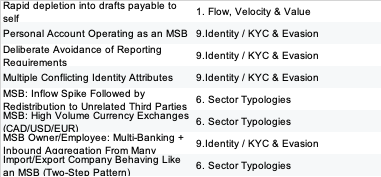

In [12]:
df = data.copy()
df["customer_id"] = df["customer_id"].astype("string")
df["tx_ts"] = pd.to_datetime(df["transaction_datetime"], errors="coerce", utc=True)
df = df[df["tx_ts"].notna()].copy()

df["dc"] = df["debit_credit"].astype("string").str.strip().str.lower()
df["amt"] = pd.to_numeric(df["amount_cad"], errors="coerce")
df = df[df["amt"].notna()].copy()

credits_all = (
    df[df["dc"].isin(["credit", "cr", "c"])]
    [["customer_id", "tx_ts", "amt"]]
    .rename(columns={"tx_ts": "credit_ts", "amt": "credit_amt"})
)

debits_all = (
    df[df["dc"].isin(["debit", "dr", "d"])]
    [["customer_id", "tx_ts", "amt"]]
    .rename(columns={"tx_ts": "debit_ts", "amt": "debit_amt"})
)

def asof_within_customer(cust_id):
    c = credits_all[credits_all["customer_id"] == cust_id].sort_values("credit_ts")
    d = debits_all[debits_all["customer_id"] == cust_id].sort_values("debit_ts")
    if c.empty or d.empty:
        return None

    out = pd.merge_asof(
        d.reset_index(drop=True),
        c.reset_index(drop=True),
        left_on="debit_ts",
        right_on="credit_ts",
        direction="backward",
        allow_exact_matches=True
    )
    out["customer_id"] = cust_id
    return out

cust_ids = pd.Index(df["customer_id"].unique())

linked_parts = []
for cid in cust_ids:
    res = asof_within_customer(cid)
    if res is not None:
        linked_parts.append(res)

linked = pd.concat(linked_parts, ignore_index=True)

linked["hours_since_credit"] = (linked["debit_ts"] - linked["credit_ts"]).dt.total_seconds() / 3600
linked = linked[(linked["hours_since_credit"] >= 0) & (linked["hours_since_credit"] <= 168)]  # up to 7 days

# ---------------------------
# Rapid depletion flags
# ---------------------------
linked["deplete_24h"] = linked["hours_since_credit"] <= 24
linked["deplete_72h"] = linked["hours_since_credit"] <= 72

# ---------------------------
# Aggregate to customer level
# ---------------------------
features = linked.groupby("customer_id").agg(
    # Velocity
    median_hours_to_depletion=("hours_since_credit", "median"),
    min_hours_to_depletion=("hours_since_credit", "min"),

    # Frequency
    rapid_depletions_24h=("deplete_24h", "sum"),
    rapid_depletions_72h=("deplete_72h", "sum"),

    # Value
    rapid_debit_sum_72h=("debit_amt", lambda x: x[linked.loc[x.index, "deplete_72h"]].sum()),
    max_single_debit=("debit_amt", "max"),
    mean_debit_size=("debit_amt", "mean"),
).reset_index()

# ---------------------------
# Add inflow context
# ---------------------------
inflow = credits_all.groupby("customer_id").agg(
    total_inflow=("credit_amt", "sum"),
    mean_inflow=("credit_amt", "mean"),
).reset_index()

features = features.merge(inflow, on="customer_id", how="left")

# ---------------------------
# Final AML-style ratios
# ---------------------------
features["rapid_depletion_ratio_72h"] = (
    features["rapid_debit_sum_72h"] / features["total_inflow"]
)

features["max_debit_to_inflow_ratio"] = (
    features["max_single_debit"] / features["total_inflow"]
)


# 6. Sector Typologies

THIS SECTION TAKES >10 MINS TO RUN

## MSB: Inflow Spike Followed by Redistribution to Unrelated Third Parties (Loans/Investments Cover)
1) wk_inflow_spike_ratio
Largest weekly inflow ÷ median weekly inflow

2) wk_outflow_spike_ratio
Largest weekly outflow ÷ median weekly outflow

3) wk_post_spike_outflow_ratio
Outflow shortly after peak inflow ÷ peak inflow

4) pass_through_ratio
Total outflow ÷ total inflow

5) high_velocity_weeks
Number of weeks with both high inflow and high outflow

## MSB: High Volume Currency Exchanges (CAD/USD/EUR)

1) tx_per_active_day

2) median_tx_amount

3) amt_iqr (tight distributions → exchange-like)

4) abs_net_flow_ratio
|net flow| ÷ total flow

5) credit_debit_symmetry
min(inflow, outflow) ÷ max(inflow, outflow)

## Import/Export Company Behaving Like an MSB (Two-Step Pattern)

1) import_export_flag (industry keyword)

2) top_inflow_share
Largest inflow ÷ total inflow

3) outflow_tx_count

4) outflow_after_inflow_ratio

5) two_step_score (composite)


In [13]:
### MSB: Inflow Spike Followed by Redistribution to Unrelated Third Parties (Loans/Investments Cover)
df = data.copy()
df["tx_ts"] = pd.to_datetime(
    df["transaction_datetime"],
    format="mixed",     # handles rows with/without seconds
    utc=True,
    errors="coerce"
)
# drop the ones that failed parsing
df = df[df["tx_ts"].notna()].copy()

df["amt"] = pd.to_numeric(df["amount_cad"], errors="coerce")
df = df.dropna(subset=["tx_ts", "amt"])

df["dc"] = df["debit_credit"].str.lower()
df["signed_amt"] = np.where(df["dc"].isin(["debit","dr","d"]), -df["amt"], df["amt"])

df["week"] = df["tx_ts"].dt.to_period("W").dt.start_time

weekly = (
    df.groupby(["customer_id", "week"])
      .agg(
          wk_in=("amt", lambda x: x[df.loc[x.index, "signed_amt"] > 0].sum()),
          wk_out=("amt", lambda x: x[df.loc[x.index, "signed_amt"] < 0].sum()),
      )
      .reset_index()
)

def spike_ratio(s):
    med = np.median(s[s > 0]) if (s > 0).any() else np.nan
    return s.max() / med if med and med > 0 else np.nan

msb_flow = weekly.groupby("customer_id").agg(
    wk_inflow_spike_ratio=("wk_in", spike_ratio),
    wk_outflow_spike_ratio=("wk_out", spike_ratio),
    total_inflow=("wk_in", "sum"),
    total_outflow=("wk_out", "sum"),
).reset_index()

msb_flow["pass_through_ratio"] = (
    msb_flow["total_outflow"] / msb_flow["total_inflow"]
)

### MSB: High Volume Currency Exchanges (CAD/USD/EUR) — proxy
daily = (
    df.groupby(["customer_id", df["tx_ts"].dt.date])
      .agg(
          day_in=("amt", lambda x: x[df.loc[x.index,"signed_amt"] > 0].sum()),
          day_out=("amt", lambda x: x[df.loc[x.index,"signed_amt"] < 0].sum()),
          day_total=("amt", "sum"),   # total volume that day (in+out magnitude proxy)
          tx_n=("amt", "size")
      )
      .reset_index()
)

daily["day_avg_tx_amt"] = daily["day_total"] / daily["tx_n"]

fx_proxy = daily.groupby("customer_id").agg(
    fx_tx_per_active_day=("tx_n","mean"),
    fx_total_in=("day_in","sum"),
    fx_total_out=("day_out","sum"),
    fx_median_day_avg_tx_amt=("day_avg_tx_amt","median"),
    fx_iqr_day_avg_tx_amt=("day_avg_tx_amt", lambda s: s.quantile(0.75) - s.quantile(0.25)),
).reset_index()

fx_proxy["fx_abs_net_flow_ratio"] = (
    (fx_proxy["fx_total_in"] - fx_proxy["fx_total_out"]).abs() /
    (fx_proxy["fx_total_in"] + fx_proxy["fx_total_out"])
)

fx_proxy["fx_credit_debit_symmetry"] = (
    np.minimum(fx_proxy["fx_total_in"], fx_proxy["fx_total_out"]) /
    np.maximum(fx_proxy["fx_total_in"], fx_proxy["fx_total_out"])
)

### Import/Export Company Behaving Like an MSB (Two-Step Pattern)
# Industry keyword flag
ind = (
    data.groupby("customer_id")["industry"]
        .first()
        .astype("string")
        .str.lower()
)

import_export = ind.str.contains(
    "import|export|trading|wholesale|logistics|freight",
    regex=True,
    na=False
)

flows = df.groupby("customer_id").agg(
    total_in=("amt", lambda x: x[df.loc[x.index,"signed_amt"] > 0].sum()),
    max_in=("amt", lambda x: x[df.loc[x.index,"signed_amt"] > 0].max()),
    out_tx_n=("amt", lambda x: (df.loc[x.index,"signed_amt"] < 0).sum())
).reset_index()

flows["top_inflow_share"] = flows["max_in"] / flows["total_in"]
flows["import_export_flag"] = flows["customer_id"].map(import_export)

flows["two_step_score"] = (
    flows["import_export_flag"].astype(int) *
    flows["top_inflow_share"] *
    np.log1p(flows["out_tx_n"])
)


/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_52616/3249660858.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["tx_ts"].dt.to_period("W").dt.start_time


In [14]:
def ensure_string_id(df, col="customer_id"):
    df[col] = df[col].astype("string")
    return df

def safe_rename(df, mapping):
    """Rename only keys that exist in df."""
    existing = {k: v for k, v in mapping.items() if k in df.columns}
    return df.rename(columns=existing)

def prefix_collisions(base, addon, prefix, key="customer_id"):
    """If addon has columns that already exist in base (besides key), prefix them."""
    addon = addon.copy()
    collide = (set(addon.columns) & set(base.columns)) - {key}
    if collide:
        addon = addon.rename(columns={c: f"{prefix}{c}" for c in collide})
    return addon

# --- ensure ids ---
features = ensure_string_id(features)
msb_flow  = ensure_string_id(msb_flow)
fx_proxy  = ensure_string_id(fx_proxy)
flows     = ensure_string_id(flows)

# --- renames (match whatever your tables currently contain) ---
msb_flow = safe_rename(msb_flow, {
    "total_inflow": "msb_total_inflow_wk",
    "total_outflow": "msb_total_outflow_wk",
    "wk_total_in": "msb_total_inflow_wk",
    "wk_total_out": "msb_total_outflow_wk",
    "pass_through_ratio": "msb_pass_through_ratio",
    "wk_pass_through_ratio": "msb_pass_through_ratio",
})

fx_proxy = safe_rename(fx_proxy, {
    # old names (if you had them)
    "total_in": "fx_total_in",
    "total_out": "fx_total_out",
    "tx_per_active_day": "fx_tx_per_active_day",
    "median_tx_amount": "fx_median_tx_amount",
    "amt_iqr": "fx_amt_iqr",
    "abs_net_flow_ratio": "fx_abs_net_flow_ratio",
    "credit_debit_symmetry": "fx_credit_debit_symmetry",

    # new names from the corrected block (keep as-is, but included for clarity)
    "fx_total_in": "fx_total_in",
    "fx_total_out": "fx_total_out",
    "fx_tx_per_active_day": "fx_tx_per_active_day",
    "fx_median_day_avg_tx_amt": "fx_median_day_avg_tx_amt",
    "fx_iqr_day_avg_tx_amt": "fx_iqr_day_avg_tx_amt",
    "fx_abs_net_flow_ratio": "fx_abs_net_flow_ratio",
    "fx_credit_debit_symmetry": "fx_credit_debit_symmetry",
})

flows = safe_rename(flows, {
    "total_in": "ie_total_in",
    "max_in": "ie_max_in",
    "out_tx_n": "ie_out_tx_n",
    "top_inflow_share": "ie_top_inflow_share",
    "import_export_flag": "ie_import_export_flag",
    "two_step_score": "ie_two_step_score",
})

# --- prevent accidental overwrites by prefixing any remaining collisions ---
msb_flow = prefix_collisions(features, msb_flow, prefix="msb_", key="customer_id")
fx_proxy = prefix_collisions(features, fx_proxy, prefix="fx_",  key="customer_id")
flows    = prefix_collisions(features, flows,    prefix="ie_",  key="customer_id")

# --- merge onto features ---
features = (
    features
      .merge(msb_flow, on="customer_id", how="left")
      .merge(fx_proxy, on="customer_id", how="left")
      .merge(flows, on="customer_id", how="left")
)


# 9.Identity / KYC & Evasion

## Personal Account Operating as an MSB
1) msb_tx_n
Total number of transactions.

2) msb_active_days
Number of distinct days with transaction activity.

3) msb_channels_n
Number of distinct transaction channels used.

4) msb_tx_per_day
Average number of transactions per active day.

5) msb_in_total
Total incoming transaction value.

6) msb_out_total
Total outgoing transaction value.

7) msb_pass_through_ratio
Outgoing ÷ incoming value (high values indicate pass-through behavior).

8) msb_net_retention_ratio
Net retained funds relative to total flow (low values indicate minimal retention).

9) flag_personal_msb_proxy
Flags customers with high frequency, high pass-through, and multi-channel activity.

## Deliberate Avoidance of Reporting Requirements
1) struct_total_near_n
Total number of near-threshold transactions.

2) struct_days_with_near
Number of days with at least one near-threshold transaction.

3) struct_max_near_in_day
Maximum number of near-threshold transactions in a single day.

4) struct_total_near_sum
Total value of near-threshold transactions.

5) flag_structuring_proxy
Flags customers with repeated near-threshold activity across multiple days.

## Multiple Conflicting Identity Attributes
1) tx_country_n
Number of distinct transaction countries.

2) tx_province_n
Number of distinct transaction provinces.

3) tx_city_n
Number of distinct transaction cities.

4) pct_tx_province_mismatch (if available)
Share of transactions occurring in a province different from KYC province.

5) pct_tx_city_mismatch (if available)
Share of transactions occurring in a city different from KYC city.

6) flag_identity_geo_conflict
Flags customers with high geographic inconsistency relative to KYC.

## MSB Owner/Employee: Multi-Banking + Inbound Aggregation From Many Sources → Drafts Payable to Self / Real Estate
1) msb_occupation_flag
Indicates MSB-related occupation keywords in KYC (e.g., remittance, exchange).

2) in_channels_n
Number of distinct channels used for inbound transactions.

3) in_tx_n
Number of inbound transactions.

4) in_amt_mean
Mean inbound transaction value.

5) in_amt_std
Standard deviation of inbound transaction values.

6) in_amt_max
Largest inbound transaction.

7) in_amt_cv
Coefficient of variation of inbound amounts (dispersion proxy).

8) flag_msb_owner_employee_proxy
Flags customers with MSB-related occupations and rapid post-inflow depletion.

In [15]:
df = data.copy()
df["customer_id"] = df["customer_id"].astype("string")

df["tx_ts"] = pd.to_datetime(df["transaction_datetime"], format="mixed", utc=True, errors="coerce")
df["amt"] = pd.to_numeric(df["amount_cad"], errors="coerce")
df = df.dropna(subset=["tx_ts", "amt"])

dc = df["debit_credit"].astype("string").str.strip().str.lower()
df["signed_amt"] = np.where(dc.isin(["debit","dr","d"]), -df["amt"],
                     np.where(dc.isin(["credit","cr","c"]), df["amt"], np.nan))
df = df.dropna(subset=["signed_amt"])

df["day"] = df["tx_ts"].dt.floor("D")


### Personal Account Operating as an MSB
msb_personal = df.groupby("customer_id").agg(
    msb_tx_n=("amt", "size"),
    msb_active_days=("day", "nunique"),
    msb_channels_n=("channel", "nunique"),
    msb_in_total=("amt", lambda x: x[df.loc[x.index, "signed_amt"] > 0].sum()),
    msb_out_total=("amt", lambda x: x[df.loc[x.index, "signed_amt"] < 0].sum()),
).reset_index()

msb_personal["msb_tx_per_day"] = np.where(
    msb_personal["msb_active_days"] > 0,
    msb_personal["msb_tx_n"] / msb_personal["msb_active_days"],
    np.nan
)

msb_personal["msb_pass_through_ratio"] = np.where(
    msb_personal["msb_in_total"] > 0,
    msb_personal["msb_out_total"] / msb_personal["msb_in_total"],
    np.nan
)

msb_personal["msb_net_retention_ratio"] = np.where(
    (msb_personal["msb_in_total"] + msb_personal["msb_out_total"]) > 0,
    (msb_personal["msb_in_total"] - msb_personal["msb_out_total"]) /
    (msb_personal["msb_in_total"] + msb_personal["msb_out_total"]),
    np.nan
)

### Deliberate Avoidance of Reporting Requirements
THRESH = 10000
BAND = 1000  # look at [9000, 9999.99]

df["near_thresh"] = df["amt"].between(THRESH - BAND, THRESH, inclusive="left")

daily_struct = (
    df.groupby(["customer_id", "day"])
      .agg(
          day_near_n=("near_thresh", "sum"),
          day_near_sum=("amt", lambda x: x[df.loc[x.index, "near_thresh"]].sum()),
      )
      .reset_index()
)

structuring = daily_struct.groupby("customer_id").agg(
    struct_total_near_n=("day_near_n", "sum"),
    struct_days_with_near=("day_near_n", lambda s: int((s > 0).sum())),
    struct_max_near_in_day=("day_near_n", "max"),
    struct_total_near_sum=("day_near_sum", "sum"),
).reset_index()

### Multiple Conflicting Identity Attributes
conflict_geo = df.groupby("customer_id").agg(
    tx_country_n=("tx_country", lambda s: s.dropna().nunique() if "tx_country" in df.columns else np.nan),
    tx_province_n=("tx_province", lambda s: s.dropna().nunique() if "tx_province" in df.columns else np.nan),
    tx_city_n=("tx_city", lambda s: s.dropna().nunique() if "tx_city" in df.columns else np.nan),
).reset_index()

# mismatch rate vs KYC (if those columns exist)
if all(c in df.columns for c in ["tx_province", "kyc_province"]):
    mismatch = df.assign(prov_mismatch=(df["tx_province"] != df["kyc_province"])).groupby("customer_id")["prov_mismatch"].mean()
    conflict_geo = conflict_geo.merge(mismatch.rename("pct_tx_province_mismatch").reset_index(), on="customer_id", how="left")

if all(c in df.columns for c in ["tx_city", "kyc_city"]):
    mismatch = df.assign(city_mismatch=(df["tx_city"] != df["kyc_city"])).groupby("customer_id")["city_mismatch"].mean()
    conflict_geo = conflict_geo.merge(mismatch.rename("pct_tx_city_mismatch").reset_index(), on="customer_id", how="left")

### MSB Owner/Employee: Multi-Banking + Inbound Aggregation From Many Sources → Drafts Payable to Self / Real Estate
# If occupation_title exists in your merged data
if "occupation_title" in data.columns:
    occ = (data.groupby("customer_id")["occupation_title"]
              .apply(lambda s: s.dropna().astype("string").iloc[0] if s.dropna().any() else pd.NA)
              .astype("string").str.lower())
    msb_occ_flag = occ.str.contains("money|msb|remittance|exchange|currency|wire|transfer|pawn", regex=True, na=False)
    msb_occ_flag = msb_occ_flag.rename("msb_occupation_flag").reset_index()
else:
    msb_occ_flag = pd.DataFrame({"customer_id": df["customer_id"].unique(), "msb_occupation_flag": False})

in_agg = df[df["signed_amt"] > 0].groupby("customer_id").agg(
    in_channels_n=("channel", "nunique"),
    in_tx_n=("amt", "size"),
    in_amt_mean=("amt", "mean"),
    in_amt_std=("amt", "std"),
    in_amt_max=("amt", "max"),
).reset_index()

# simple dispersion proxy: std/mean (higher = lumpier inbound aggregation)
in_agg["in_amt_cv"] = in_agg["in_amt_std"] / in_agg["in_amt_mean"]

In [16]:
# Ensure string keys
for df_ in [msb_personal, structuring, conflict_geo, msb_occ_flag, in_agg]:
    df_["customer_id"] = df_["customer_id"].astype("string")

# Rename to avoid collisions with existing features columns (safe practice)
msb_personal = msb_personal.rename(columns={
    "msb_in_total": "id_msb_in_total",
    "msb_out_total": "id_msb_out_total",
})

# Build features table (customers present in msb_personal)
features = (
    msb_personal
      .merge(structuring,  on="customer_id", how="left")
      .merge(conflict_geo, on="customer_id", how="left")
      .merge(msb_occ_flag, on="customer_id", how="left")
      .merge(in_agg,       on="customer_id", how="left")
)

# Optional: fill count-like NaNs with 0 (leave ratios/totals as NaN)
count_cols = [
    "msb_tx_n","msb_active_days","msb_channels_n",
    "struct_total_near_n","struct_days_with_near","struct_max_near_in_day",
    "tx_country_n","tx_province_n","tx_city_n",
    "in_channels_n","in_tx_n"
]
for c in count_cols:
    if c in features.columns:
        features[c] = features[c].fillna(0)

# ---- Derived MSB metrics (must exist before flags) ----
features["msb_tx_per_day"] = np.where(
    features["msb_active_days"] > 0,
    features["msb_tx_n"] / features["msb_active_days"],
    np.nan
)

features["msb_pass_through_ratio"] = np.where(
    features["id_msb_in_total"] > 0,
    features["id_msb_out_total"] / features["id_msb_in_total"],
    np.nan
)

features["msb_net_retention_ratio"] = np.where(
    (features["id_msb_in_total"] + features["id_msb_out_total"]) > 0,
    (features["id_msb_in_total"] - features["id_msb_out_total"]) /
    (features["id_msb_in_total"] + features["id_msb_out_total"]),
    np.nan
)

# ---- Flags ----
features["flag_personal_msb_proxy"] = (
    (features["msb_tx_per_day"] > 20) &
    (features["msb_pass_through_ratio"] > 0.9) &
    (features["msb_channels_n"] >= 3)
)

features["flag_structuring_proxy"] = (
    (features["struct_days_with_near"] >= 3) &
    (features["struct_max_near_in_day"] >= 2)
)

features["flag_identity_geo_conflict"] = (
    (features.get("pct_tx_province_mismatch", 0) > 0.5) |
    (features.get("pct_tx_city_mismatch", 0) > 0.5)
)

features["flag_msb_owner_employee_proxy"] = (
    (features.get("msb_occupation_flag", False) == True) &
    (features.get("rapid_depletion_ratio_72h", 0) > 0.8)
)


### Merge new features back onto merged dataset

In [17]:
data_engineered = data.merge(
    features,
    on="customer_id",
    how="left",
    validate="many_to_one")

In [18]:
data_engineered.head()

,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,cash_indicator,tx_country,tx_province,tx_city,channel,...,in_channels_n,in_tx_n,in_amt_mean,in_amt_std,in_amt_max,in_amt_cv,flag_personal_msb_proxy,flag_structuring_proxy,flag_identity_geo_conflict,flag_msb_owner_employee_proxy
0,ABM2411016110810,SYNID0104291988,300.0,D,2024-11-01 00:01,1.0,CA,BC,other,ABM,...,3.0,9.0,302.418889,347.504109,900.00,1.149082,False,False,True,False
1,ABM2411013831558,SYNID0103664053,400.0,C,2024-11-01 00:03,1.0,CA,NS,other,ABM,...,5.0,36.0,524.947500,561.594717,1990.48,1.069811,False,False,True,False
2,ABM2411013725020,SYNID0106747172,400.0,D,2024-11-01 00:03,1.0,CA,BC,SURREY,ABM,...,4.0,33.0,716.836970,838.983127,3099.09,1.170396,False,False,True,False
3,ABM2411012851967,SYNID0106306354,320.0,D,2024-11-01 00:03,1.0,CA,BC,other,ABM,...,3.0,8.0,602.520000,979.357982,2894.95,1.625436,False,False,True,False
4,ABM2411018908251,SYNID0105732044,1000.0,D,2024-11-01 00:04,1.0,CA,BC,SURREY,ABM,...,0.0,0.0,NaN,NaN,NaN,NaN,False,False,True,False


In [19]:
data_engineered.columns

Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime', 'cash_indicator', 'tx_country', 'tx_province',
       'tx_city', 'channel', 'merchant_category', 'ecommerce_ind',
       'birth_date', 'kyc_city', 'kyc_country', 'customer_type',
       'employee_count', 'established_date', 'gender', 'income', 'industry',
       'industry_code', 'marital_status', 'occupation_code',
       'occupation_title', 'onboard_date', 'kyc_province', 'sales', 'label',
       'msb_tx_n', 'msb_active_days', 'msb_channels_n', 'id_msb_in_total',
       'id_msb_out_total', 'msb_tx_per_day', 'msb_pass_through_ratio',
       'msb_net_retention_ratio', 'struct_total_near_n',
       'struct_days_with_near', 'struct_max_near_in_day',
       'struct_total_near_sum', 'tx_country_n', 'tx_province_n', 'tx_city_n',
       'pct_tx_province_mismatch', 'pct_tx_city_mismatch',
       'msb_occupation_flag', 'in_channels_n', 'in_tx_n', 'in_amt_mean',
       'in_amt_std', 'in_amt_max',

In [20]:
#data_engineered.to_csv("features_rebecca.csv", index=False)